In [1]:
import os
os.environ['MEMORY_LIMIT'] = '16GB'
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import gridspec
from os.path import exists, join
from io import StringIO  
from datetime import timedelta
import math

ALGORITHMS = {
    'structural': 'Structural',
    'structural-variant': 'Splitted Structural',
    'sed': 'Sed',
    'lblint': 'Lbl-Int',
    'bib': 'Binary branch',
    'sedindex': 'Sed Index',
    'lblindex': 'Lbl-Int Index',
    'structuralindex': 'Structural Index',
}

datasets = ('dblp', 'ptb', 'python', 'sentiment', 'swissprot', 'treefam')
ALGORITHMS_ENUM_NAMES = {
    'structural': 'Structural',
    'structural-variant': 'StructuralVariant',
    'sed': 'Sed',
    'lblint': 'Lblint',
    'bib': 'Bib'
}

In [71]:
qdf = pd.DataFrame()

BASEPATH = 'resources/workloads/generated/'
# fanout = ['high-fanout', 'medhigh-fanout', 'medium-fanout', 'low-fanout']
# fanout = ['ultrahigh-fanout', 'high-fanout', 'medium-fanout', 'low-fanout', 'ultralow-fanout']
# datasets = [f'pairs-fanout-{fo}-30' for fo in fanout] # change of structure - mainly subtree moves - 5 labels - 3 edits min

# fanout = ['ultrahigh-fanout', 'high-fanout', 'medium-fanout', 'mid-fanout', 'small-fanout', 'verysmall-fanout', 'low-fanout']
# datasets = [f'struct-change-fanout-{fo}-30' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min
# datasets = [f'struct-change-fanout-{fo}-30-labels-8' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min

# last result
fanout = ['ultrahigh-fanout', 'high-fanout', 'mid-fanout', 'medium-fanout', 'small-fanout']
datasets = [f'struct-change-{fo}-60-labels-5' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min
# datasets = ['unbalanced-c3-80-p00', 'unbalanced-c3-80-p01', 'unbalanced-c3-80-p015', 'unbalanced-c3-80-p02', 'unbalanced-c3-80-p025', 'unbalanced-c3-80-p035', 'unbalanced-c3-80-p05', 'unbalanced-c3-80-p10']

# datasets = [f'adjusted-unbalanced-c3-60-p{str(ds).replace('.', '')}' for ds in [ 0,0.15,0.2,0.25,0.5, 0.7, 1]]
# datasets = [f'adjusted-unbalanced-c3-30-p{str(ds).replace('.', '')}' for ds in [ 0,0.15,0.2,0.25,0.5, 0.7, 1]]

# datasets = [f'gen-fanout-{fo}-30' for fo in fanout] # generated - change of labels 
# datasets = [f'fanout-{fo}-30' for fo in fanout]

# fanout = [(5, 'small-fanout'), (50, 'small-fanout'), (500, 'small-fanout'), (5000, 'small-fanout')]
# datasets = [f'labels-{lo}-fanout-{fo}-30' for lo, fo in fanout] # change of structure with labels edits - 3 edits min

# TODO: Dodelat dataset aby SED a SEDStruct meli stejnou precision

# fanout = ['high-fanout', 'mid-fanout', 'medium-fanout', 'small-fanout', 'low-fanout']
# datasets = [f'struct-label-change-fanout-{fo}-30' for fo in fanout] # change of structure with labels edits - 3 edits min

# fanout = ['ultrahigh-fanout', 'high-fanout', 'mid-fanout', 'small-fanout', 'low-fanout']
# fanout = ['ultrahigh-fanout', 'high-fanout', 'mid-fanout', 'medium-fanout']
fanout = ['high-fanout', 'medium-fanout', 'small-fanout', 'low-fanout']
datasets = [f'struct-change-3-fanout-{fo}-60-labels-20' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min


for ds in datasets:
    full_path_sed = join(BASEPATH, f'{ds}/query-sed-ukkonen.csv')
    full_path_sedstruct = join(BASEPATH, f'{ds}/query-sed-struct-ukkonen.csv')
    # read second line of file
    with open(full_path_sed) as f:
        lines = f.readlines()
        reg_time = float(lines[1].strip('ms\n').split(':')[1])
    with open(full_path_sedstruct) as f:
        lines = f.readlines()
        uk_time = float(lines[1].strip('ms\n').split(':')[1])
    tdf = pd.DataFrame({
        'Dataset': [ds] * 2,
        'Method': ['SED', 'SEDStruct'],
        'SearchTime': [reg_time, uk_time]
    })
    qdf = pd.concat([qdf, tdf])

display(qdf)

,Dataset,Method,SearchTime
0,struct-change-3-fanout-high-fanout-60-labels-20,SED,26.0
1,struct-change-3-fanout-high-fanout-60-labels-20,SEDStruct,42.0
0,struct-change-3-fanout-medium-fanout-60-labels-20,SED,39.0
1,struct-change-3-fanout-medium-fanout-60-labels-20,SEDStruct,57.0
0,struct-change-3-fanout-small-fanout-60-labels-20,SED,34.0
1,struct-change-3-fanout-small-fanout-60-labels-20,SEDStruct,53.0
0,struct-change-3-fanout-low-fanout-60-labels-20,SED,40.0
1,struct-change-3-fanout-low-fanout-60-labels-20,SEDStruct,63.0


<Axes: xlabel='None-Method', ylabel='Dataset'>

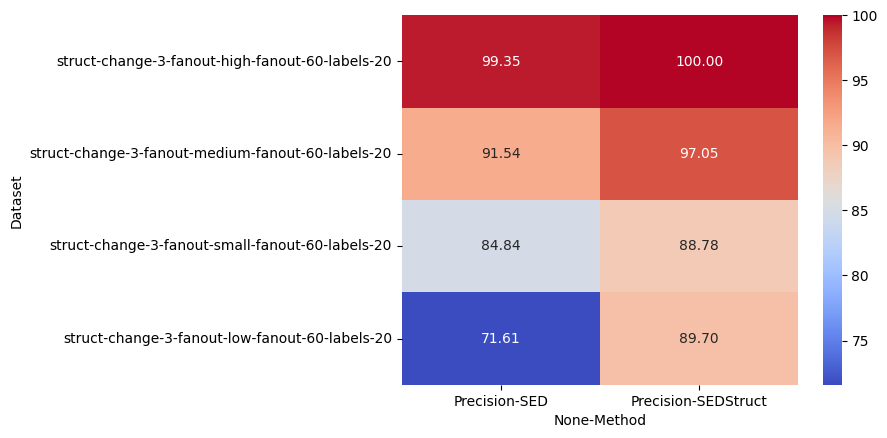

In [72]:
all_sed_candidates = pd.DataFrame()
all_sedstruct_candidates = pd.DataFrame()
for ds in datasets:
    sed_candidates = pd.read_csv(join(BASEPATH, f'{ds}/Sed_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sedstruct_candidates = pd.read_csv(join(BASEPATH, f'{ds}/SEDStruct_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sed_candidates.insert(0, 'Dataset', ds)
    sedstruct_candidates.insert(0, 'Dataset', ds)
    all_sed_candidates = pd.concat([all_sed_candidates, sed_candidates])
    all_sedstruct_candidates = pd.concat([all_sedstruct_candidates, sedstruct_candidates])
    
all_vdf = pd.DataFrame()
for ds in datasets:
    vdf = pd.read_csv(join(BASEPATH, f'{ds}/verified-all.csv'), engine="python", skipfooter=1)
    vdf.insert(0, 'Dataset', ds)
    all_vdf = pd.concat([all_vdf, vdf])
    
sed_joined = all_sed_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')
sedstruct_joined = all_sedstruct_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')

# Calculate verification times for each dataset separately
for dataset in datasets:
    sed_dataset_time = sed_joined[sed_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
    sedstruct_dataset_time = sedstruct_joined[sedstruct_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
    
    # Update the qdf dataframe for each dataset
    qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SED'), 'VerificationTime'] = sed_dataset_time
    qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SEDStruct'), 'VerificationTime'] = sedstruct_dataset_time
    
# Get SED precision
sed_precision = all_sed_candidates.groupby('Dataset').size().reset_index(name='SED_Total')
sed_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SED_Passed')
sed_precision = sed_precision.merge(sed_passed, on='Dataset', how='left').fillna(0)
sed_precision['Method'] = 'SED'
sed_precision['Precision'] = (sed_precision['SED_Passed'] / sed_precision['SED_Total']) * 100

#  Get SEDStruct precision
sedstruct_precision = all_sedstruct_candidates.groupby('Dataset').size().reset_index(name='SEDStruct_Total')
sedstruct_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SEDStruct_Passed')
sedstruct_precision = sedstruct_precision.merge(sedstruct_passed, on='Dataset', how='left').fillna(0)
sedstruct_precision['Method'] = 'SEDStruct'
sedstruct_precision['Precision'] = (sedstruct_precision['SEDStruct_Passed'] / sedstruct_precision['SEDStruct_Total']) * 100

# Combine results
precision_df = pd.concat([
    sed_precision[['Dataset', 'Method', 'SED_Total', 'SED_Passed', 'Precision']].rename(columns={'SED_Total': 'Total', 'SED_Passed': 'Passed'}),
    sedstruct_precision[['Dataset', 'Method', 'SEDStruct_Total', 'SEDStruct_Passed', 'Precision']].rename(columns={'SEDStruct_Total': 'Total', 'SEDStruct_Passed': 'Passed'})
])

precision_df

pdf = precision_df.pivot(index=['Dataset'], columns=['Method'], values=['Precision'])
pdf = pdf.reindex(datasets)
pdf

sns.heatmap(pdf, annot=True, fmt='.2f', cmap='coolwarm')

In [73]:
all_df = pd.DataFrame()
for ds in datasets:
  ldf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'tree_leafs.csv'), header=None)
  sdf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'tree_sizes.csv'), header=None)
  ddf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'avg_degrees.csv'), header=None)
  nddf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'degrees.csv'), header=None)
  combined_df = pd.concat([ldf, sdf, ddf, nddf], axis=1)
  combined_df.columns = ['leaf_count', 'tree_size', 'avg_degree', 'node_degree']
  combined_df['Dataset'] = ds
  
  all_df = pd.concat([all_df, combined_df], ignore_index=True)
  
all_df['leaf_percentage'] = (all_df['leaf_count'] / all_df['tree_size']) * 100
all_df
agg = all_df.groupby('Dataset').agg({'leaf_count': ['mean', 'sum', 'median', 'std'], 'tree_size': ['mean', 'sum', 'median', 'std'], 'leaf_percentage': ['mean', 'median', 'std']})

In [77]:
all_df

,leaf_count,tree_size,avg_degree,node_degree,Dataset,leaf_percentage
0,45.0,62.0,3.588235,38,struct-change-3-fanout-high-fanout-60-labels-20,72.580645
1,44.0,62.0,3.388889,1,struct-change-3-fanout-high-fanout-60-labels-20,70.967742
2,43.0,62.0,3.210526,1,struct-change-3-fanout-high-fanout-60-labels-20,69.354839
3,45.0,62.0,3.588235,3,struct-change-3-fanout-high-fanout-60-labels-20,72.580645
4,45.0,62.0,3.588235,1,struct-change-3-fanout-high-fanout-60-labels-20,72.580645
...,...,...,...,...,...,...
542327,NaN,NaN,NaN,1,struct-change-3-fanout-low-fanout-60-labels-20,NaN
542328,NaN,NaN,NaN,2,struct-change-3-fanout-low-fanout-60-labels-20,NaN
542329,NaN,NaN,NaN,2,struct-change-3-fanout-low-fanout-60-labels-20,NaN
542330,NaN,NaN,NaN,1,struct-change-3-fanout-low-fanout-60-labels-20,NaN


/tmp/ipykernel_6767/3958659649.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bx = sns.boxplot(data=all_df.dropna(subset=['tree_size']), x='Dataset', y='avg_degree', palette='Set3')


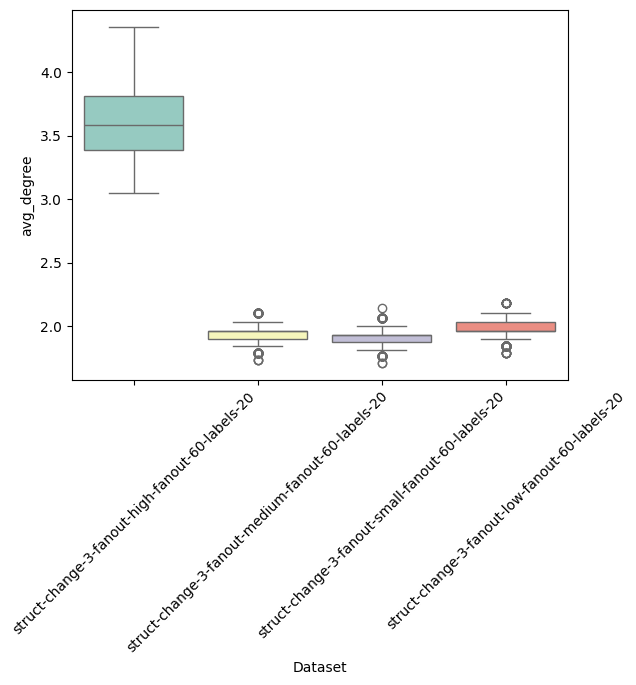

In [79]:
bx = sns.boxplot(data=all_df.dropna(subset=['tree_size']), x='Dataset', y='avg_degree', palette='Set3')
bx.tick_params(axis="x", rotation=45)

<Axes: xlabel='avg_degree', ylabel='Density'>

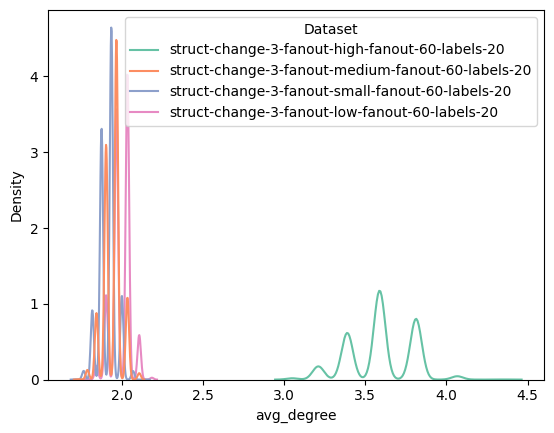

In [94]:
sns.kdeplot(data=all_df, x='avg_degree', hue='Dataset', palette='Set2')

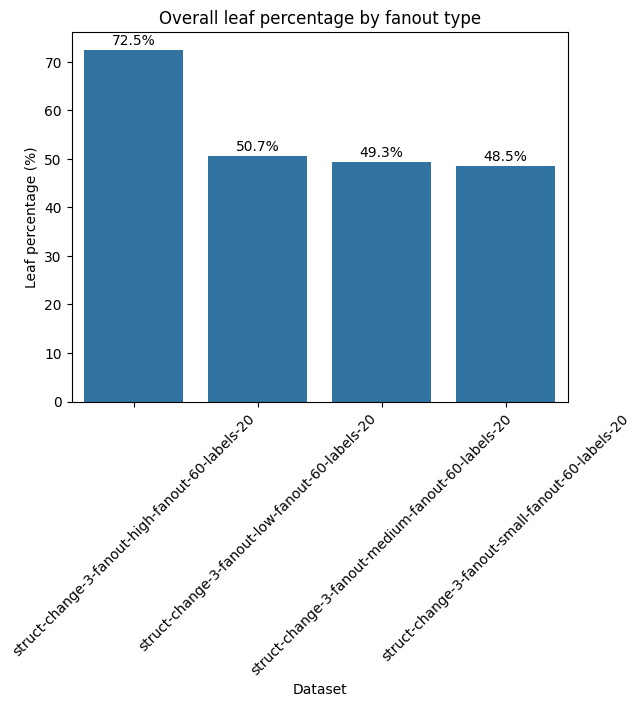

In [76]:
agg['leaf_percentage_col'] = (agg['leaf_count']['sum'] / agg['tree_size']['sum']) * 100
ax = sns.barplot(data=agg, x='Dataset', y='leaf_percentage_col')

# Annotate bars with actual values
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom')

plt.ylabel('Leaf percentage (%)')
plt.title('Overall leaf percentage by fanout type')
ax.tick_params(axis='x', rotation=45)